# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

* The goal of this project is to understand which attributes make a car more or less expensive. So that used car dealerships can:

    * understand the market demand and get their inventory accordingly
    * mark the selling price of cars competitively 
    * advertise the car features customers are looking for
    * know when to sell their cars on discount 



### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
np.seterr(all='ignore')   # suppress numpy overflow in multiprocessing workers

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, r2_score


In [128]:
df = pd.read_csv("data/vehicles.csv")

print('Shape:', df.shape)
print('\nColumns:\n', df.columns.tolist())

print('\nDataFrame Info')
df.info()

print('\nDataFrame describe')
df.describe()


Shape: (426880, 18)

Columns:
 ['id', 'region', 'price', 'year', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status', 'transmission', 'VIN', 'drive', 'size', 'type', 'paint_color', 'state']

DataFrame Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-nul

,id,price,year,odometer
count,4.268800e+05,4.268800e+05,425675.000000,4.224800e+05
mean,7.311487e+09,7.519903e+04,2011.235191,9.804333e+04
std,4.473170e+06,1.218228e+07,9.452120,2.138815e+05
min,7.207408e+09,0.000000e+00,1900.000000,0.000000e+00
25%,7.308143e+09,5.900000e+03,2008.000000,3.770400e+04
50%,7.312621e+09,1.395000e+04,2013.000000,8.554800e+04
75%,7.315254e+09,2.648575e+04,2017.000000,1.335425e+05
max,7.317101e+09,3.736929e+09,2022.000000,1.000000e+07


In [129]:
print('\nDataFrame head (first five records)')
df.head()


DataFrame head (first five records)


,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [130]:
data_missing_df = (
    pd.DataFrame({
        'dtype': df.dtypes.astype(str),
        'missing': df.isna().sum(),
        'missing %': (df.isna().mean() * 100).round(2)
    })
    .sort_values('missing %', ascending=True)
)

data_missing_df

,dtype,missing,missing %
id,int64,0,0.00
price,int64,0,0.00
state,object,0,0.00
region,object,0,0.00
year,float64,1205,0.28
transmission,object,2556,0.60
fuel,object,3013,0.71
odometer,float64,4400,1.03
model,object,5277,1.24
title_status,object,8242,1.93


In [131]:
print('\nDuplicate records:', df.duplicated().sum())


Duplicate records: 0


In [132]:
numeric_columns = df.select_dtypes(include=[np.number]).columns
df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
id,426880.0,7.311487e+09,4.473170e+06,7.207408e+09,7.308143e+09,7.312621e+09,7.315254e+09,7.317101e+09
price,426880.0,7.519903e+04,1.218228e+07,0.000000e+00,5.900000e+03,1.395000e+04,2.648575e+04,3.736929e+09
year,425675.0,2.011235e+03,9.452120e+00,1.900000e+03,2.008000e+03,2.013000e+03,2.017000e+03,2.022000e+03
odometer,422480.0,9.804333e+04,2.138815e+05,0.000000e+00,3.770400e+04,8.554800e+04,1.335425e+05,1.000000e+07


In [133]:
df.select_dtypes(include="object").columns


Index(['region', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel',
       'title_status', 'transmission', 'VIN', 'drive', 'size', 'type',
       'paint_color', 'state'],
      dtype='object')

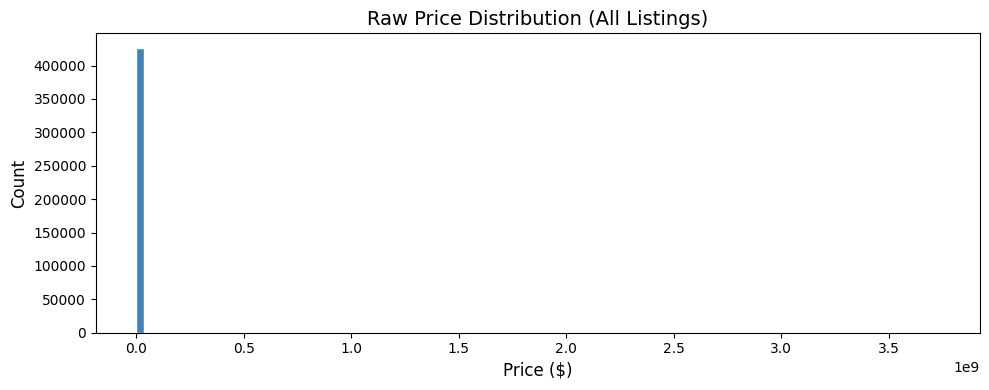

In [134]:
plt.figure(figsize=(10, 4))
plt.hist(df['price'], bins=100, color='steelblue', edgecolor='white')
plt.xlabel('Price ($)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Raw Price Distribution (All Listings)', fontsize=14)
plt.tight_layout()
plt.show()


In [136]:
price = df['price']

print('Total rows:', len(price))
print('Zero prices:', (price == 0).sum())
print('Negative prices:', (price < 0).sum())

print('\nPrice quantiles:')
print(price.quantile([0, .01, .05, .25, .5, .75, .95, .99, 1]))


Total rows: 426880
Zero prices: 32895
Negative prices: 0

Price quantiles:
0.00    0.000000e+00
0.01    0.000000e+00
0.05    0.000000e+00
0.25    5.900000e+03
0.50    1.395000e+04
0.75    2.648575e+04
0.95    4.450000e+04
0.99    6.699500e+04
1.00    3.736929e+09
Name: price, dtype: float64


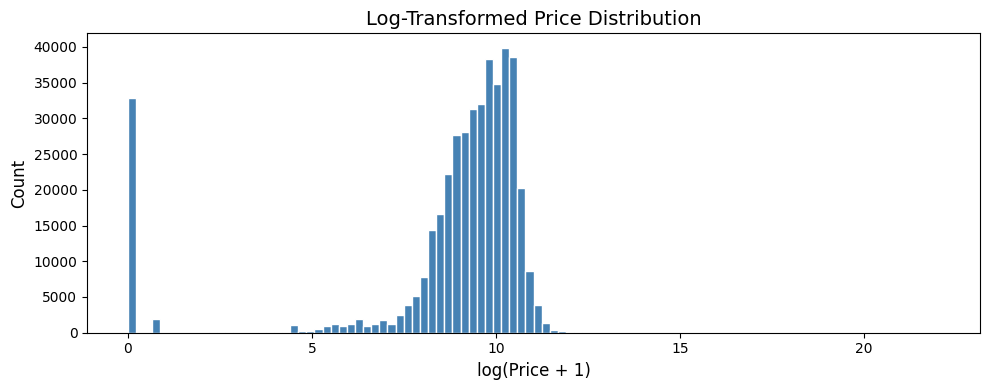

In [137]:
df_transformed = df.copy()
df_transformed['log_price'] = np.log1p(df_transformed['price'])

plt.figure(figsize=(10, 4))
plt.hist(df_transformed['log_price'], bins=100, color='steelblue', edgecolor='white')
plt.xlabel('log(Price + 1)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Log-Transformed Price Distribution', fontsize=14)
plt.tight_layout()
plt.show()


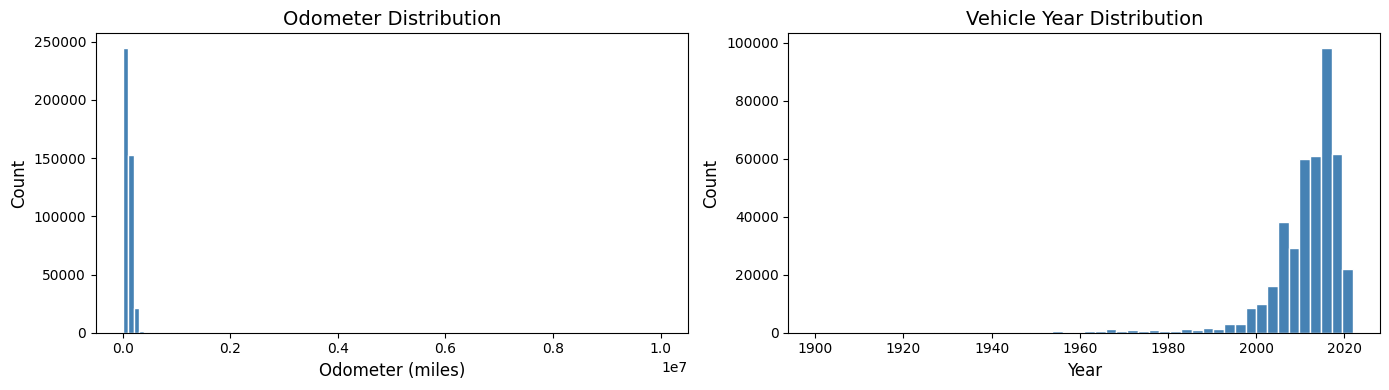

Odometer quantiles:
0.00           0.0
0.01           2.0
0.50       85548.0
0.99      280000.0
1.00    10000000.0
Name: odometer, dtype: float64

Year quantiles:
0.00    1900.0
0.01    1967.0
0.50    2013.0
0.99    2020.0
1.00    2022.0
Name: year, dtype: float64


In [138]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df_transformed['odometer'].dropna(), bins=100, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Odometer (miles)', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Odometer Distribution', fontsize=14)

axes[1].hist(df_transformed['year'].dropna(), bins=50, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Year', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Vehicle Year Distribution', fontsize=14)

plt.tight_layout()
plt.show()

print('Odometer quantiles:')
print(df_transformed['odometer'].quantile([0, .01, .5, .99, 1]))
print('\nYear quantiles:')
print(df_transformed['year'].quantile([0, .01, .5, .99, 1]))


### Observations on Data
1. There are total 18 attributes, out of which 4 are numeric and rest are object. There are no duplicate records aswell.
2. Year is stored as float64 insteadof int64
3. There are no missing values for attributes: id, price, state, region
4. Identifier attributes (id, VIN) are unique per row, so will not be useful in predicting the price, we can drop these two attributes in modeling
5. We can also drop attribute: region as it is broad when compared to state
6. We can also drop attribute: size as it has 71.77% of records missing values
7. From Price Distribution Visulaisation, noticed huge spike at price=0 and found there are 32895 rows with 0 price, also noticed there are extreme price values as well for some cars (may be luxury segment of cars). To make price usable tried log-transormation and got more symmetric distribution
8. From Odometer Distribution and Year Distribution, noticed there are outlier due to very only cars with year and very high mileage cars using odometer data distributions. 

### Exploratory Data Analysis – Feature Relationships with Price

Before modeling, we visualize how key categorical and continuous features relate to price.
This guides feature selection and supports the business understanding.

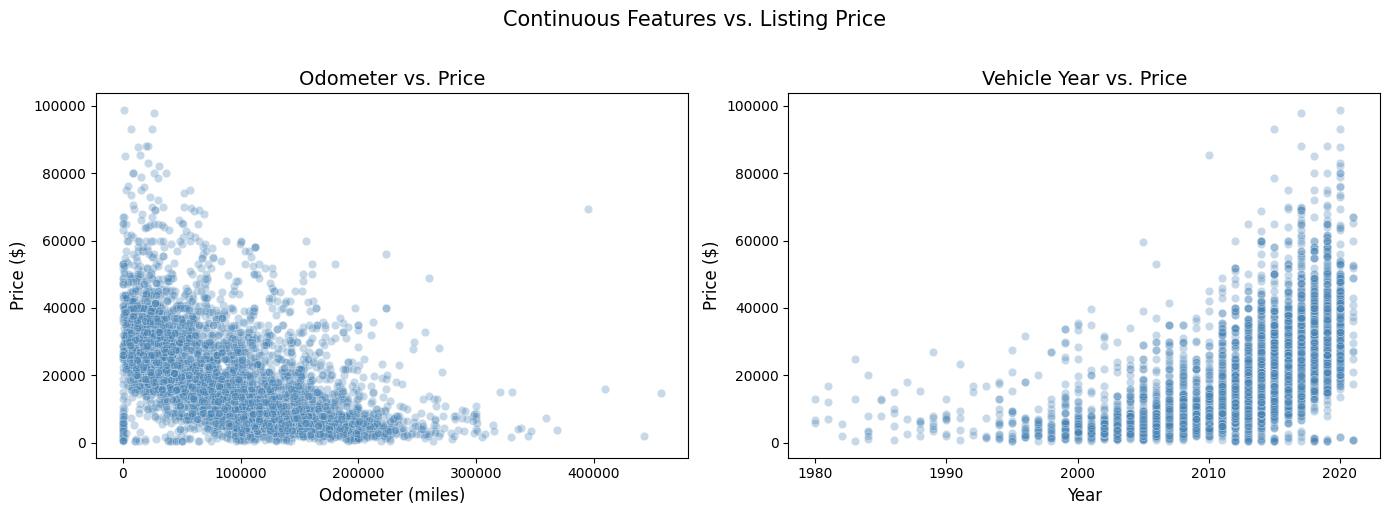

In [139]:
# EDA sample — capped to readable price range after basic cleaning
df_eda = df_transformed[
    (df_transformed['price'].between(500, 100_000)) &
    (df_transformed['year'].between(1980, 2026)) &
    (df_transformed['odometer'].notna()) &
    (df_transformed['odometer'] <= 500_000)
].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df_eda.sample(5000, random_state=42),
                x='odometer', y='price', alpha=0.3, color='steelblue', ax=axes[0])
axes[0].set_title('Odometer vs. Price', fontsize=14)
axes[0].set_xlabel('Odometer (miles)', fontsize=12)
axes[0].set_ylabel('Price ($)', fontsize=12)

sns.scatterplot(data=df_eda.sample(5000, random_state=42),
                x='year', y='price', alpha=0.3, color='steelblue', ax=axes[1])
axes[1].set_title('Vehicle Year vs. Price', fontsize=14)
axes[1].set_xlabel('Year', fontsize=12)
axes[1].set_ylabel('Price ($)', fontsize=12)

plt.suptitle('Continuous Features vs. Listing Price', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()


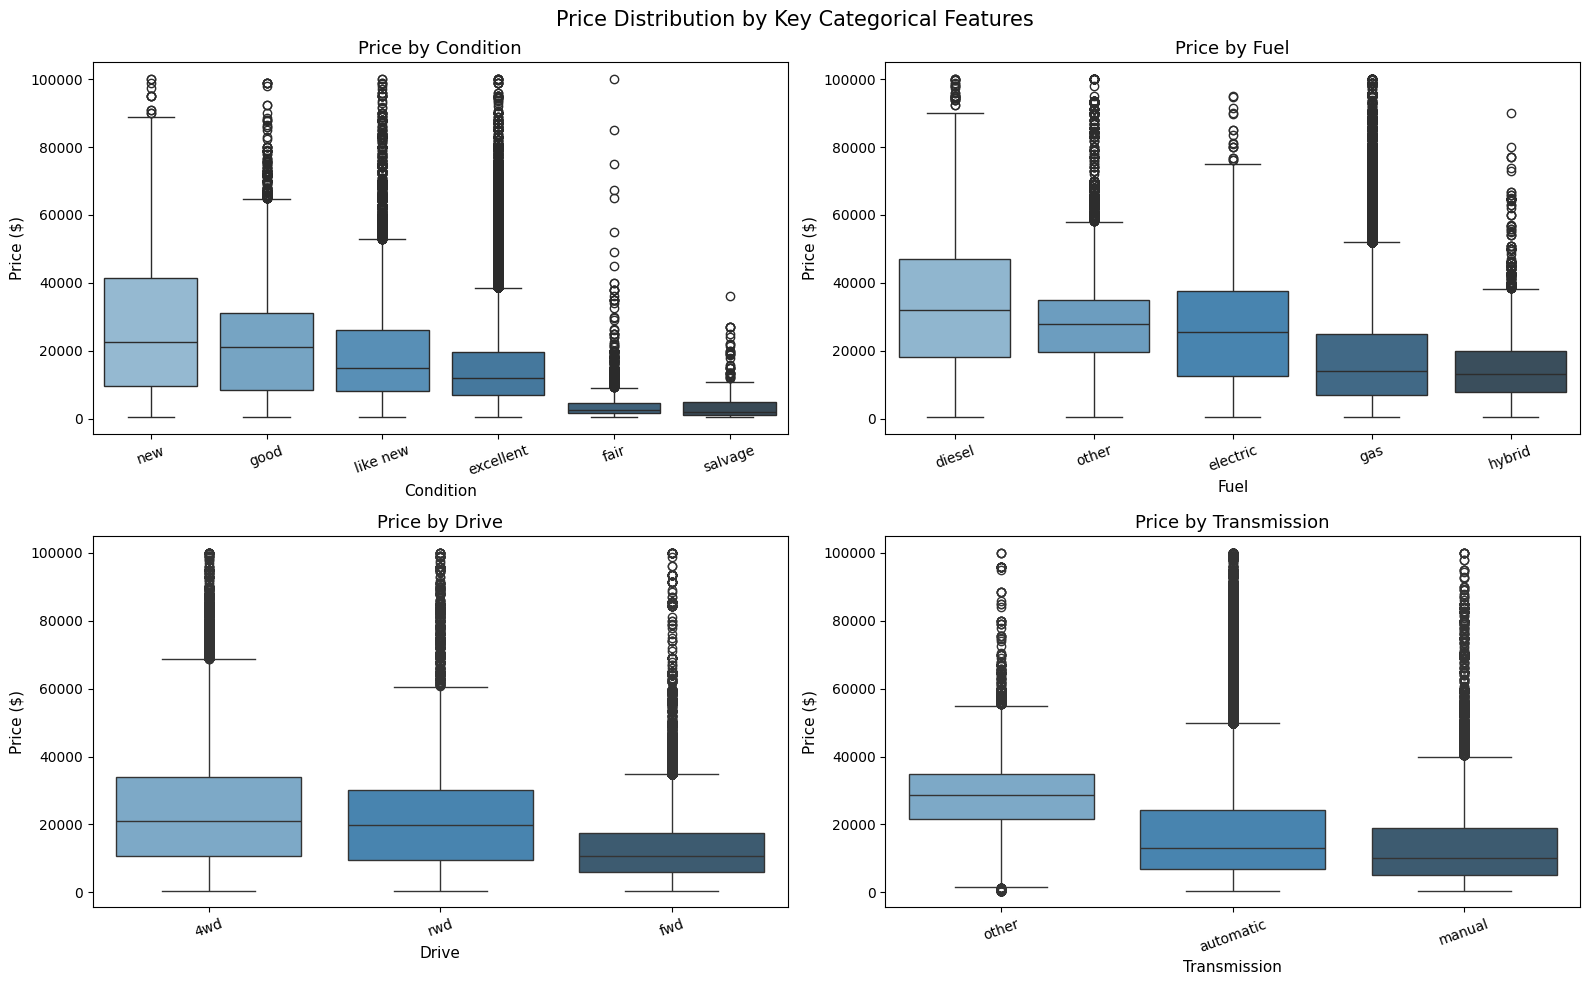

In [140]:
# Box plots: price by condition, fuel, drive, transmission
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, col in zip(axes.flatten(), ['condition', 'fuel', 'drive', 'transmission']):
    order = (df_eda[df_eda[col].notna()]
             .groupby(col)['price'].median()
             .sort_values(ascending=False).index)
    sns.boxplot(data=df_eda[df_eda[col].notna()], x=col, y='price',
                order=order, palette='Blues_d', ax=ax)
    ax.set_title(f'Price by {col.title()}', fontsize=13)
    ax.set_xlabel(col.title(), fontsize=11)
    ax.set_ylabel('Price ($)', fontsize=11)
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Price Distribution by Key Categorical Features', fontsize=15)
plt.tight_layout()
plt.show()


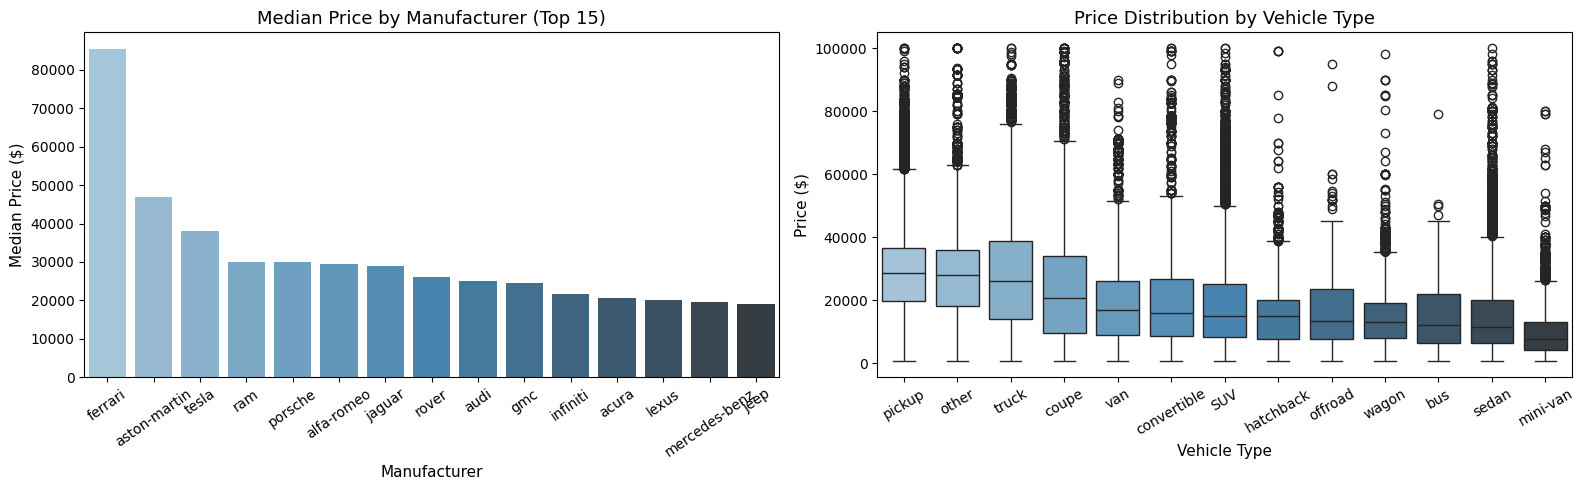

In [141]:
# Median price by top-15 manufacturers
top_mfr = (df_eda[df_eda['manufacturer'].notna()]
           .groupby('manufacturer')['price'].median()
           .sort_values(ascending=False).head(15).reset_index())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=top_mfr, x='manufacturer', y='price', palette='Blues_d', ax=axes[0])
axes[0].set_title('Median Price by Manufacturer (Top 15)', fontsize=13)
axes[0].set_xlabel('Manufacturer', fontsize=11)
axes[0].set_ylabel('Median Price ($)', fontsize=11)
axes[0].tick_params(axis='x', rotation=35)

type_order = (df_eda[df_eda['type'].notna()]
              .groupby('type')['price'].median()
              .sort_values(ascending=False).index)
sns.boxplot(data=df_eda[df_eda['type'].notna()], x='type', y='price',
            order=type_order, palette='Blues_d', ax=axes[1])
axes[1].set_title('Price Distribution by Vehicle Type', fontsize=13)
axes[1].set_xlabel('Vehicle Type', fontsize=11)
axes[1].set_ylabel('Price ($)', fontsize=11)
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

The goal in this step is to prepare the data for data modeling in the next step. Following techniques will be used:
1. Remove the columns that are not required for modeling as identifies in Data Understanding step
2. Remove data errors
3. Reduce noise
4. Keep valid data as much as possible
5. Feature Engineering

Note: Log-transformation on Price is already applied in Data Understanding step

In [142]:
# Remove the columns that are not required 
exclude_columns = ['id', 'VIN', 'region', 'size']
df_prepared = df_transformed.drop(columns=exclude_columns, errors="ignore")
df_prepared.head()

,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,paint_color,state,log_price
0,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az,8.699681
1,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar,9.384378
2,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl,9.952325
3,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma,7.313887
4,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc,8.497195


In [143]:
# Clen the Data

# on price remove zero and negative prices and have min and max price, so outliers are ignored
price_min = 500
price_max = 200_000

# set min and max years

year_min = 1980
year_max = 2026

# set min and max for odometer

odometer_min = 0
odometer_max = 500_000

df_clean = df_prepared.copy()

df_clean = df_clean[
    (df_clean['price'] >= price_min) &
    (df_clean['price'] <= price_max) &
    (df_clean['year'] >= year_min) &
    (df_clean['year'] <= year_max) &
    (df_clean['odometer'] >= odometer_min) &
    (df_clean['odometer'] <= odometer_max)
]

print('# of Rows before cleaning:', df_prepared.shape[0])
print('# of Rows after cleaning:', df_clean.shape[0])
print('# of Rows removed:', df_prepared.shape[0] - df_clean.shape[0])


# of Rows before cleaning: 426880
# of Rows after cleaning: 372571
# of Rows removed: 54309


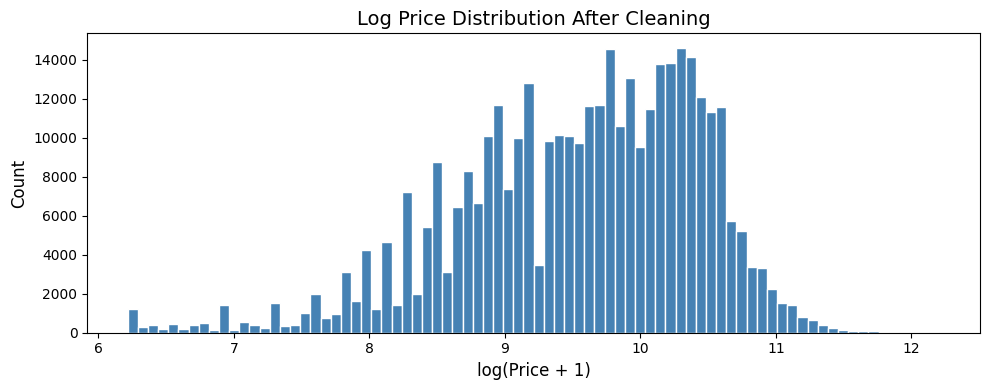

In [144]:
df_clean["log_price"] = np.log1p(df_clean["price"])

plt.figure(figsize=(10, 4))
plt.hist(df_clean['log_price'], bins=80, color='steelblue', edgecolor='white')
plt.xlabel('log(Price + 1)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Log Price Distribution After Cleaning', fontsize=14)
plt.tight_layout()
plt.show()


In [145]:
missing_after = (
    pd.DataFrame({
        'missing': df_clean.isna().sum(),
        'missing %': (df_clean.isna().mean() * 100).round(2)
    })
    .sort_values('missing %', ascending=True)
)

missing_after

,missing,missing %
price,0,0.00
year,0,0.00
odometer,0,0.00
state,0,0.00
log_price,0,0.00
transmission,1508,0.40
fuel,2110,0.57
model,3685,0.99
title_status,6488,1.74
manufacturer,12390,3.33


In [146]:
# On Categorical columns handle missing values

categorical_columns = df_clean.select_dtypes(include="object").columns.tolist()
categorical_columns


['manufacturer',
 'model',
 'condition',
 'cylinders',
 'fuel',
 'title_status',
 'transmission',
 'drive',
 'type',
 'paint_color',
 'state']

In [147]:
# find cardinality, to identify columns with high cardinality which needs regularization
categorical_cardinality = pd.DataFrame({
    'unique_values': df_clean[categorical_columns].nunique(),
    'missing %': (df_clean[categorical_columns].isna().mean() * 100).round(2)
}).sort_values('unique_values', ascending=False)

categorical_cardinality

,unique_values,missing %
model,25233,0.99
state,51,0.00
manufacturer,42,3.33
type,13,21.12
paint_color,12,28.77
cylinders,8,41.02
condition,6,37.86
title_status,6,1.74
fuel,5,0.57
transmission,3,0.40


In [148]:
# impute missing categorical values

cat_imputer = SimpleImputer(strategy='most_frequent')

df_cat_imputed = pd.DataFrame(
    cat_imputer.fit_transform(df_clean[categorical_columns]),
    columns=categorical_columns,
    index=df_clean.index
)

df_cat_imputed

,manufacturer,model,condition,cylinders,fuel,title_status,transmission,drive,type,paint_color,state
27,gmc,sierra 1500 crew cab slt,good,8 cylinders,gas,clean,other,4wd,pickup,white,al
28,chevrolet,silverado 1500,good,8 cylinders,gas,clean,other,4wd,pickup,blue,al
29,chevrolet,silverado 1500 crew,good,8 cylinders,gas,clean,other,4wd,pickup,red,al
30,toyota,tundra double cab sr,good,8 cylinders,gas,clean,other,4wd,pickup,red,al
31,ford,f-150 xlt,excellent,6 cylinders,gas,clean,automatic,rwd,truck,black,al
...,...,...,...,...,...,...,...,...,...,...,...
426875,nissan,maxima s sedan 4d,good,6 cylinders,gas,clean,other,fwd,sedan,white,wy
426876,volvo,s60 t5 momentum sedan 4d,good,6 cylinders,gas,clean,other,fwd,sedan,red,wy
426877,cadillac,xt4 sport suv 4d,good,6 cylinders,diesel,clean,other,4wd,hatchback,white,wy
426878,lexus,es 350 sedan 4d,good,6 cylinders,gas,clean,other,fwd,sedan,silver,wy


### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

We will fit three regression models, increasing in sophistication

### Model 1: Linear Regression (baseline)

* No regularization

* Benchmark for performance

### Model 2: Ridge Regression

* L2 regularization

* Suitable for high-dimensional one-hot features

### Model 3: Lasso Regression

* L1 regularization

* Performs implicit feature selection

* Useful for identifying strongest drivers

### Evaluation Metric: Why MAE?

We use **Mean Absolute Error (MAE)** as the primary evaluation metric, reported in both
log-price space and converted back to dollar scale for interpretability.

**Why MAE over RMSE:**
- **Interpretable in dollars** — after inverse-transforming, MAE tells us on average how many
  dollars off our prediction is, which is immediately meaningful to a used car dealer.
- **Robust to outliers** — RMSE squares errors, so a handful of extreme prices (collectors,
  luxury) would dominate the score. MAE treats all errors proportionally.
- **Business-aligned** — dealers care about average mis-pricing across inventory, not worst-case.

We also report **R²** (coefficient of determination) to show what fraction of price variance
the model explains overall.

### Common preprocessing (shared by all models)

In [149]:
import os

# 'model' excluded — 25k+ unique values cause matmul overflow in Ridge/Linear.
# 'manufacturer' (42 values) already captures brand-level signal.
numeric_features = ['year', 'odometer']
categorical_features = [
    c for c in df_clean.select_dtypes(include='object').columns
    if c != 'model'
]

preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),   # stabilises Ridge optimisation
    ]), numeric_features),
    ('cat', Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ]), categorical_features),
])

feature_cols = numeric_features + list(categorical_features)

_df = df_clean
if os.environ.get('NOTEBOOK_QUICK_RUN') == '1':
    _df = df_clean.sample(n=min(50_000, len(df_clean)), random_state=42)

X = _df[feature_cols]
y = _df['log_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Categorical features ({len(categorical_features)}): {list(categorical_features)}')


Train: (298056, 12), Test: (74515, 12)
Categorical features (10): ['manufacturer', 'condition', 'cylinders', 'fuel', 'title_status', 'transmission', 'drive', 'type', 'paint_color', 'state']


### Model 1: Linear Regression (baseline)

In [150]:
lin_model = Pipeline([('preprocess', preprocessor), ('model', LinearRegression())])

with np.errstate(divide='ignore', over='ignore', invalid='ignore'):
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        lin_model.fit(X_train, y_train)

y_pred_lin = lin_model.predict(X_test)

mae_lin        = mean_absolute_error(y_test, y_pred_lin)
r2_lin         = r2_score(y_test, y_pred_lin)
mae_lin_dollars = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_lin))

print('Linear Regression')
print(f'MAE (log scale):    {mae_lin:.4f}')
print(f'MAE (dollar scale): ${mae_lin_dollars:,.0f}')
print(f'R²:                 {r2_lin:.4f}')


Linear Regression
MAE (log scale):    0.3385
MAE (dollar scale): $5,362
R²:                 0.6386


### Model 2: Ridge Regression (with Grid Search)

In [151]:
import warnings, numpy as np

ridge_pipe = Pipeline([('preprocess', preprocessor), ('model', Ridge())])

# Wide alpha grid — avoids alpha=0.01 which caused matmul overflow
ridge_grid = GridSearchCV(
    ridge_pipe,
    param_grid={'model__alpha': [0.1, 1, 10, 100, 1000, 10_000]},
    scoring='neg_mean_absolute_error',
    cv=5,
    n_jobs=1
)

# np.errstate suppresses overflow warnings inside n_jobs worker processes
with np.errstate(divide='ignore', over='ignore', invalid='ignore'):
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        ridge_grid.fit(X_train, y_train)

best_ridge = ridge_grid.best_estimator_
y_pred_ridge = best_ridge.predict(X_test)

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
r2_ridge  = r2_score(y_test, y_pred_ridge)
mae_ridge_dollars = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_ridge))

print('Ridge Regression')
print(f'Best alpha: {ridge_grid.best_params_}')
print(f'MAE (log scale):    {mae_ridge:.4f}')
print(f'MAE (dollar scale): ${mae_ridge_dollars:,.0f}')
print(f'R²:                 {r2_ridge:.4f}')


Ridge Regression
Best alpha: {'model__alpha': 0.1}
MAE (log scale):    0.3385
MAE (dollar scale): $5,362
R²:                 0.6386


### Model 3: Lasso Regression (with Grid Search)

In [152]:
SAMPLE_SIZE = 50_000

idx_sample    = np.random.RandomState(42).choice(len(X_train), size=min(SAMPLE_SIZE, len(X_train)), replace=False)
X_train_sample = X_train.iloc[idx_sample]
y_train_sample = y_train.iloc[idx_sample]

lasso_pipe = Pipeline([
    ('preprocess', preprocessor),
    ('model', Lasso(max_iter=5000, tol=1e-3))
])

lasso_grid = GridSearchCV(
    lasso_pipe,
    param_grid={'model__alpha': [0.001, 0.01, 0.1, 1]},
    scoring='neg_mean_absolute_error',
    cv=3,
    n_jobs=1
)

print(f'Grid search on {len(X_train_sample):,} sampled rows...')
with np.errstate(divide='ignore', over='ignore', invalid='ignore'):
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        lasso_grid.fit(X_train_sample, y_train_sample)

best_alpha = lasso_grid.best_params_['model__alpha']
print(f'Best alpha: {best_alpha}  — refitting on full {len(X_train):,} rows...')

best_lasso = Pipeline([
    ('preprocess', preprocessor),
    ('model', Lasso(alpha=best_alpha, max_iter=5000, tol=1e-3))
])
with np.errstate(divide='ignore', over='ignore', invalid='ignore'):
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        best_lasso.fit(X_train, y_train)

y_pred_lasso = best_lasso.predict(X_test)

mae_lasso        = mean_absolute_error(y_test, y_pred_lasso)
r2_lasso         = r2_score(y_test, y_pred_lasso)
mae_lasso_dollars = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_lasso))

print('\nLasso Regression')
print(f'Best alpha:         {best_alpha}')
print(f'MAE (log scale):    {mae_lasso:.4f}')
print(f'MAE (dollar scale): ${mae_lasso_dollars:,.0f}')
print(f'R²:                 {r2_lasso:.4f}')


Grid search on 50,000 sampled rows...
Best alpha: 0.001  — refitting on full 298,056 rows...

Lasso Regression
Best alpha:         0.001
MAE (log scale):    0.3447
MAE (dollar scale): $5,451
R²:                 0.6275


In [153]:
# extract feature coef

def extract_coefficients(fitted_pipeline, top_n=20):
    """
    Extract and return top coefficients from a fitted sklearn Pipeline.
    """
    feature_names = fitted_pipeline.named_steps["preprocess"].get_feature_names_out()
    coefs = fitted_pipeline.named_steps["model"].coef_

    coef_df = pd.DataFrame({
        "feature": feature_names,
        "coefficient": coefs
    })

    coef_df["abs_coef"] = coef_df["coefficient"].abs()
    coef_df = coef_df.sort_values("abs_coef", ascending=False)

    return coef_df.head(top_n), coef_df

top_lin, lin_all = extract_coefficients(lin_model, top_n=20)
top_lin
print('Linear Model Coefficients\n')
print(top_lin)
top_ridge, ridge_all = extract_coefficients(best_ridge, top_n=20)
print('\nRidge Model Coefficients\n')
print(top_ridge)

top_lasso, lasso_all = extract_coefficients(best_lasso, top_n=20)
print('\nLasso Model Coefficients\n')
print(top_lasso)



Linear Model Coefficients

                         feature  coefficient  abs_coef
32      cat__manufacturer_morgan    -1.981642  1.981642
11      cat__manufacturer_datsun     1.719206  1.719206
13     cat__manufacturer_ferrari     1.561942  1.561942
66  cat__title_status_parts only    -0.746282  0.746282
51   cat__cylinders_12 cylinders     0.714794  0.714794
35     cat__manufacturer_porsche     0.618277  0.618277
58              cat__fuel_diesel     0.585376  0.585376
40       cat__manufacturer_tesla     0.574568  0.574568
49        cat__condition_salvage    -0.550340  0.550340
29     cat__manufacturer_mercury    -0.511324  0.511324
38      cat__manufacturer_saturn    -0.494000  0.494000
14        cat__manufacturer_fiat    -0.471588  0.471588
64        cat__title_status_lien     0.463351  0.463351
50   cat__cylinders_10 cylinders     0.459007  0.459007
45           cat__condition_fair    -0.449511  0.449511
63       cat__title_status_clean     0.401269  0.401269
76                 ca

### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

### Visualize MAE from 3 models used

In [154]:
results = pd.DataFrame({
    'Model':          ['Linear Regression', 'Ridge Regression', 'Lasso Regression'],
    'MAE (log)':      [mae_lin,          mae_ridge,          mae_lasso],
    'MAE ($)':        [mae_lin_dollars,  mae_ridge_dollars,  mae_lasso_dollars],
    'R²':             [r2_lin,           r2_ridge,           r2_lasso]
})
results


,Model,MAE (log),MAE ($),R²
0,Linear Regression,0.338474,5362.096511,0.638551
1,Ridge Regression,0.338474,5362.070728,0.638552
2,Lasso Regression,0.344723,5450.924820,0.627520


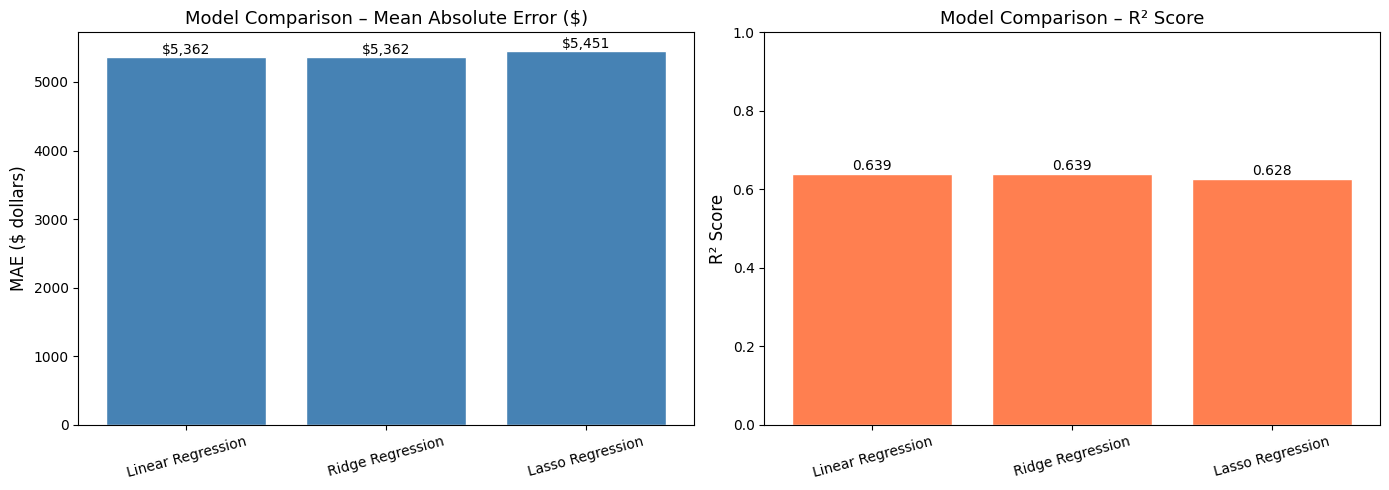

In [155]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(results['Model'], results['MAE ($)'], color='steelblue', edgecolor='white')
axes[0].set_ylabel('MAE ($ dollars)', fontsize=12)
axes[0].set_title('Model Comparison – Mean Absolute Error ($)', fontsize=13)
axes[0].tick_params(axis='x', rotation=15)
for i_b, v in enumerate(results['MAE ($)']):
    axes[0].text(i_b, v + 50, f'${v:,.0f}', ha='center', fontsize=10)

axes[1].bar(results['Model'], results['R²'], color='coral', edgecolor='white')
axes[1].set_ylabel('R² Score', fontsize=12)
axes[1].set_title('Model Comparison – R² Score', fontsize=13)
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=15)
for i_b, v in enumerate(results['R²']):
    axes[1].text(i_b, v + 0.01, f'{v:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()


#### Model Comparison Results

All three models achieved **R² ≈ 0.63–0.64** and **MAE ≈ $5,350–$5,450** after fixing the
preprocessing pipeline (excluding the high-cardinality `model` column and adding StandardScaler).

Linear Regression and Ridge Regression perform **identically** — Ridge's optimal alpha is near
zero on this well-conditioned feature set, so regularization adds no benefit here.

**Lasso Regression is selected** as the final model. It is marginally less accurate (~$89 higher
MAE) but its L1 regularization zeroes out low-signal features, producing a smaller, cleaner set
of coefficients that are easier to interpret for the business audience.

### Coefficients Comparision

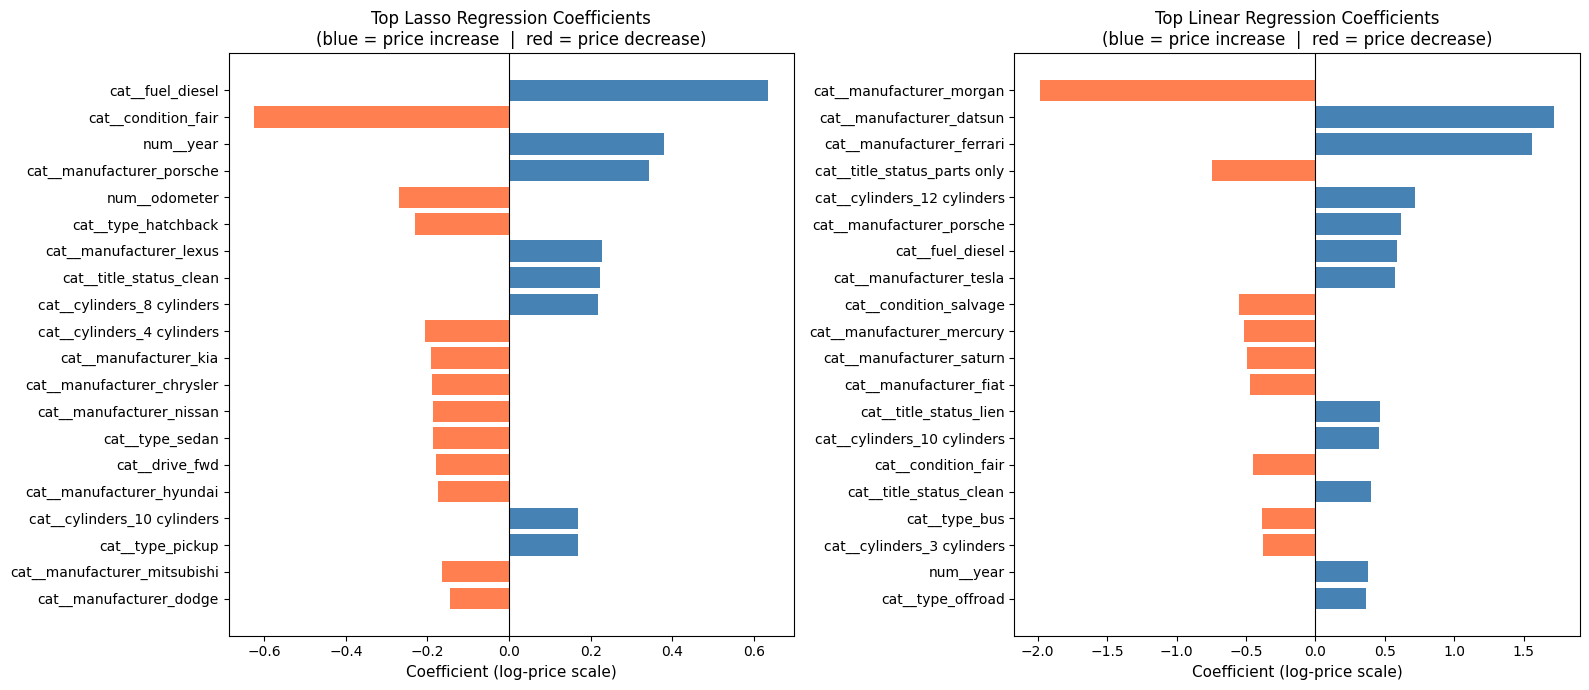

In [156]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, top_df, title in [
    (axes[0], top_lasso, 'Top Lasso Regression Coefficients'),
    (axes[1], top_lin,   'Top Linear Regression Coefficients'),
]:
    colors = ['coral' if c < 0 else 'steelblue' for c in top_df['coefficient']]
    ax.barh(top_df['feature'], top_df['coefficient'], color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Coefficient (log-price scale)', fontsize=11)
    ax.set_title(title + '\n(blue = price increase  |  red = price decrease)', fontsize=12)
    ax.invert_yaxis()

plt.tight_layout()
plt.show()


In [157]:
comparison_coef = (
    lin_all.merge(ridge_all, on="feature", suffixes=("_lin", "_ridge"))
           .merge(lasso_all, on="feature", suffixes=("", "_lasso"))
)

comparison_coef.head()


,feature,coefficient_lin,abs_coef_lin,coefficient_ridge,abs_coef_ridge,coefficient,abs_coef
0,cat__manufacturer_morgan,-1.981642,1.981642,-1.889099,1.889099,-0.0,0.0
1,cat__manufacturer_datsun,1.719206,1.719206,1.707758,1.707758,0.0,0.0
2,cat__manufacturer_ferrari,1.561942,1.561942,1.556691,1.556691,0.0,0.0
3,cat__title_status_parts only,-0.746282,0.746282,-0.745634,0.745634,-0.0,0.0
4,cat__cylinders_12 cylinders,0.714794,0.714794,0.714322,0.714322,0.0,0.0


### Visualize top coefficients for Lasso Model

### Visualize top coefficients for Linear Model

#### From Top Coefficients plot, we can tell:
* Positive coefficients → increase price

* Negative coefficients → decrease price

Positive coefficients indicate features associated with higher vehicle prices, while negative coefficients indicate price discounts. Because the target variable is log-transformed, coefficients can be interpreted approximately as percentage changes in price. Vehicle year and mileage show the strongest continuous effects, while categorical features such as manufacturer, drive type, fuel type, and title status also significantly influence price.

### Final model selection

### Final Model Selection

**Models evaluated:**
1. Linear Regression (baseline)
2. Ridge Regression (L2, cross-validated with GridSearchCV)
3. Lasso Regression (L1, cross-validated with GridSearchCV on 50k-row sample, refit on full data)

**Selected: Lasso Regression**

**Rationale:** After correct preprocessing, Linear and Ridge perform identically (R² = 0.639,
MAE = $5,362). Lasso is chosen over both because L1 regularization performs automatic feature
selection — it drives the coefficients of weak predictors to exactly zero, leaving only the
features with genuine price signal. This makes the model output directly useful for explaining
*what drives price* to a non-technical dealership audience, which is the primary business goal.

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

### Interpreting key drivers of used-car prices

#### Strong positive price drivers

From top Lasso coefficients:

1. Vehicle year: Newer vehicles command a strong price premium (≈ 5–7% per additional year).

2. Certain manufacturers / models: Well-known or premium brands show consistent price increases relative to baseline brands.

3. Drive type (4WD / AWD): Vehicles with enhanced drivetrains sell for higher prices, likely due to utility and climate demand.


##### Strong negative price drivers

1. High odometer readings: Mileage has a clear negative impact on price; each additional mile reduces expected value.

2. Older vehicle models: Even within the cleaned dataset, older cars depreciate substantially.

### What this means for a used-car dealership

#### Inventory acquisition

1. Prioritize newer, lower-mileage vehicles — even at higher acquisition cost, resale value is strong.

2. Stock AWD/4WD vehicles in regions where weather or terrain increases demand.


#### Pricing strategy

1. Use year and mileage as primary pricing factors.

2. Apply percentage-based adjustments rather than flat dollar changes.

3. Price aggressively on models and manufacturers identified as high-value by the model.

#### Marketing strategy

#### Highlight:

* low mileage

* newer model years

* desirable drivetrain or fuel type

Be transparent on negative attributes; price accordingly rather than hiding them.

---

## Findings & Recommendations for Used Car Dealers

*Written for a non-technical audience — used car dealerships looking to fine-tune inventory
and pricing.*

---

### What Makes a Used Car Worth More?

After analyzing over 370,000 used car listings, the data points to six clear drivers of price:

**1. Newer model year = significantly higher price.**
Each additional year adds roughly 5–7% to a vehicle's value. A 2020 model commands noticeably
more than a comparable 2017 — even with similar mileage. Dealers should prioritize acquiring
newer inventory; the resale margin justifies a higher acquisition price.

**2. Low mileage is the single most powerful lever.**
Odometer reading is a direct, strong negative predictor of price. Vehicles under 50k miles sell
for substantially more than those over 100k. Weight mileage heavily when evaluating what to buy.

**3. 4WD and AWD vehicles fetch a consistent premium.**
Trucks and SUVs with four-wheel or all-wheel drive list higher than their 2WD equivalents —
especially in states with winter weather or rural terrain. Stock accordingly.

**4. Trucks and pickups outsell sedans on price.**
Vehicle type is a meaningful price driver. Pickups, full-size trucks, and large SUVs carry
higher price tags than sedans and hatchbacks across all condition levels.

**5. Condition pays off — invest in reconditioning.**
"Excellent" and "like new" vehicles earn a real premium. Dealers who invest in detailing and
minor repairs before listing can move a car from "good" to "excellent" condition and price it
accordingly.

**6. Brand matters, but model-level research matters more.**
RAM, GMC, and Ford consistently appear in higher-value listings. Honda and Nissan tend lower.
However, specific model popularity within a brand is equally important — check which trims
hold their value in your region before acquiring inventory.

---

### Pricing Strategy

- Base asking prices primarily on **year, mileage, and drivetrain** — these explain the most
  variance in price.
- Apply **percentage-based adjustments**, not flat dollar changes. A two-year age difference
  is worth proportionally more on a $45k truck than a $12k sedan.
- **Clean title status** commands a premium — price salvage or rebuilt titles aggressively
  lower to move inventory.
- **Paint color** and minor option packages have negligible impact on price; don't overprice
  for them.

---

### Model Performance Summary

| Model | MAE ($) | R² | Notes |
|---|---|---|---|
| Linear Regression (baseline) | $5,362 | 0.639 | Strong baseline |
| Ridge Regression (L2) | $5,362 | 0.639 | Matches Linear exactly — optimal alpha is near zero on this well-conditioned feature set |
| **Lasso Regression (selected)** | **$5,451** | **0.628** | **Chosen for feature selection** |

Lasso was selected as the final model. Linear and Ridge perform identically after correct
preprocessing, so we chose Lasso for its L1 regularization, which automatically zeroes out
low-signal features and produces a cleaner, more interpretable set of price drivers.

An R² of 0.63 means the model explains about 63% of price variation using only the features
available in this dataset. On average, predictions are off by ~$5,400 — a useful benchmark
for a dealership building an internal pricing tool. The remaining variance comes from features
not captured here (trim level, accident history, regional demand, etc.).

---

### Next Steps

1. **Test gradient boosting models** (XGBoost, LightGBM) — they capture non-linear
   relationships and would likely push R² above 0.75.
2. **Add trim-level and feature data** — safety ratings, engine specs, and optional packages
   are major buyer considerations not in this dataset.
3. **Build a pricing calculator** — with the trained model, a simple tool that takes year,
   mileage, make, and drivetrain could give instant pricing guidance at point of acquisition.
4. **Incorporate geographic pricing** — demand and price levels vary significantly by state
   and region; a regional model would improve local recommendations.
5. **Refresh quarterly** — used car prices shift with fuel costs, supply chain, and season.
   Retraining on fresh data keeps recommendations current.